In [1]:
from google.colab import files
uploaded = files.upload()

Saving traffic.csv to traffic.csv


In [2]:
!pip install pandas numpy matplotlib seaborn plotly

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style("whitegrid")

In [5]:
df= pd.read_csv("traffic.csv")

In [15]:
df['date']=pd.to_datetime(df['date'],errors='coerce')
df.drop_duplicates(inplace=True)
df.dropna(subset=['event','date','linkid'],inplace=True)

In [16]:
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116257 entries, 0 to 226274
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   event    116257 non-null  object        
 1   date     116257 non-null  datetime64[ns]
 2   country  116257 non-null  object        
 3   city     116257 non-null  object        
 4   artist   116257 non-null  object        
 5   album    116257 non-null  object        
 6   track    116257 non-null  object        
 7   isrc     116257 non-null  object        
 8   linkid   116257 non-null  object        
dtypes: datetime64[ns](1), object(8)
memory usage: 8.9+ MB


In [18]:
df.shape

(116257, 9)

In [19]:
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

In [20]:
df.isnull().sum()

,0
event,0
date,0
country,0
city,0
artist,0
album,0
track,0
isrc,0
linkid,0


compute available metrics


In [21]:
total_events= len(df)
unique_links = df['linkid'].nunique()
unique_tracks = df['track'].nunique()
unique_artists= df['artist'].nunique()
print(total_events)
print(unique_links)
print(unique_tracks)
print(unique_artists)

116257
743
693
590


In [22]:
top_entry=df['linkid'].value_counts().head(10)
print(top_entry)

linkid
2d896d31-97b6-4869-967b-1c5fb9cd4bb8    8288
e849515b-929d-44c8-a505-e7622f1827e9    3950
522da5cc-8177-4140-97a7-a84fdb4caf1c    3786
a82e72d8-523f-43ab-9fd0-992605d54b4e    3059
681d888a-59ce-4acb-b7c5-95dab0c063d9    2865
23199824-9cf5-4b98-942a-34965c3b0cc2    2672
c2c876ab-b093-4750-9449-6b4913da6af3    2442
97105aff-3e40-4c2e-bfeb-563b55e8f5dd    2390
d5317591-872a-487d-87cb-10a516643d5f    2074
a107c329-5d35-4c7d-8050-50bc69ce7dbc    2072
Name: count, dtype: int64


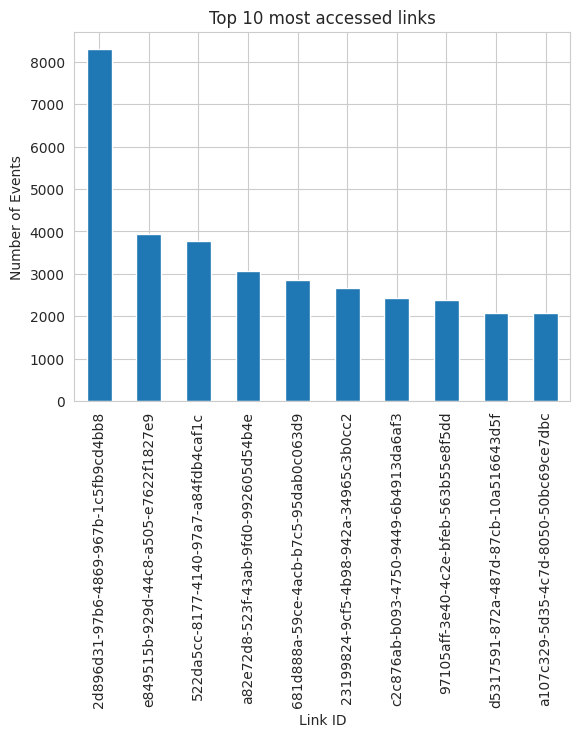

In [24]:
top_entry.plot(kind='bar')
plt.title('Top 10 most accessed links')
plt.xlabel('Link ID')
plt.ylabel('Number of Events')
plt.show()

In [28]:
flow=(df.sort_values('date').groupby('linkid')['event'].apply(list))
print(flow.head())

linkid
006af6a0-1f0d-4b0c-93bf-756af9071c06    [pageview, pageview, pageview, pageview, previ...
00759b81-3f04-4a61-b934-f8fb3185f4a0    [pageview, click, click, pageview, preview, pa...
00829040-ee01-4409-966d-d67c7965144a    [pageview, preview, pageview, click, pageview,...
009193ee-c3df-4efa-88f2-feb37c0bfdf2                   [click, pageview, click, pageview]
00de7566-f014-4d20-8616-82e4dea45b88    [preview, pageview, pageview, pageview, click,...
Name: event, dtype: object


In [29]:
country_counts = df['country'].value_counts().head(10)
print(country_counts)

country
United States     23868
India             18688
France            10547
Saudi Arabia       7464
United Kingdom     5089
Germany            3984
Pakistan           2588
Canada             2419
Turkey             2380
Iraq               2375
Name: count, dtype: int64


In [30]:
artist_counts = df['artist'].value_counts().head(10)
print(artist_counts)

artist
Tesher                                                          8288
Anne-Marie                                                      4028
Tundra Beats                                                    3950
Roddy Ricch                                                     3103
Olivia Rodrigo                                                  3025
Surf Mesa, Emilee                                               2947
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2672
PinkPantheress                                                  2444
50 Cent, Olivia                                                 2390
Name: count, dtype: int64
